# Day 5.6 — MCP: Discover, Then Govern
Model Context Protocol is a standard way for a client to ask a server *what can you do?* and then
*do this*. One client can reach tools nobody on your team wrote. It grants no authority: the server
describes itself, and your harness decides what that description is worth.

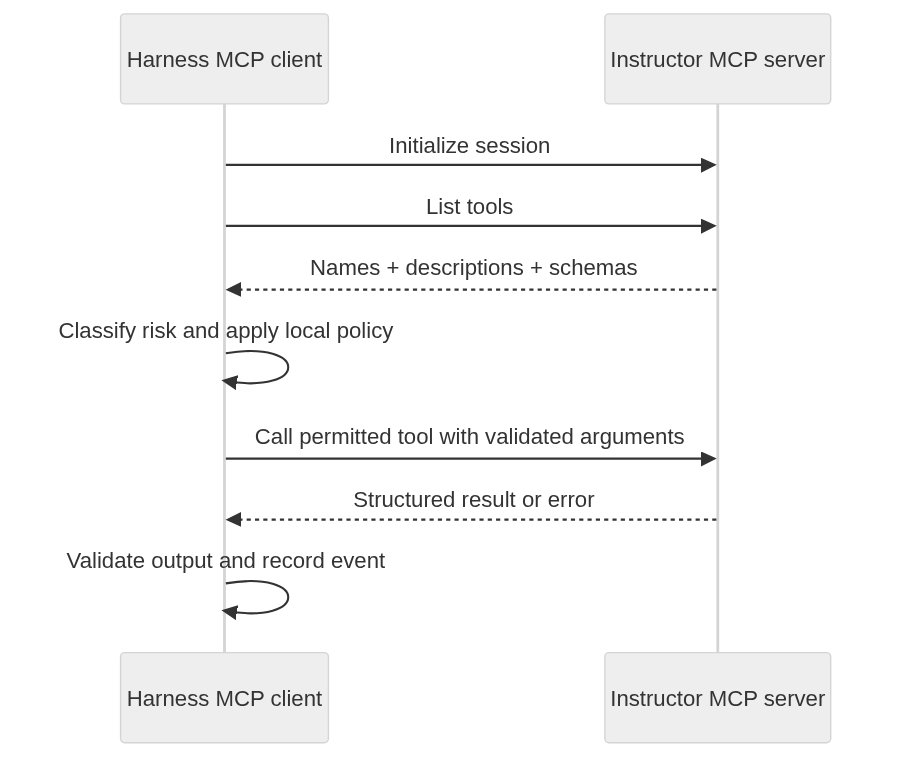

*D17 — discover, classify locally, apply policy, and only then call the tool*

### Protocol, not permission

A server may expose tools, resources or prompts, and both its descriptions and its results are
**untrusted external content**. Before importing one, weigh its origin, its schema, a *local* risk
level and which agents may use it. A server that changes its tools must not silently expand what your
application may do.

```text
discovery is not authorization
```

### Step 1 — Discovery, offline first

`FakeMCPClient` returns objects with the same three attributes the real SDK uses — `.name`,
`.description`, `.inputSchema` (camelCase, because that is what the protocol sends).

In [ ]:
@dataclass(frozen=True)
class MCPToolDescription:
    """Same attribute names the real MCP SDK's Tool object uses."""
    name: str
    description: str
    inputSchema: dict[str, Any] = field(default_factory=dict)

class FakeMCPClient:
    """Offline, protocol-shaped stand-in: used in mock mode, tests and outages."""
    async def list_tools(self):
        return [MCPToolDescription(
            name="course_lookup",
            description="Look up a synthetic course fact",
            inputSchema={"type": "object", "properties": {"topic": {"type": "string"}},
                         "required": ["topic"]})]

    async def call_tool(self, name, arguments):
        if name != "course_lookup":
            raise KeyError(name)
        return {"topic": arguments["topic"], "answer": "Synthetic MCP response"}

def tool_result_payload(result):
    """Normalise a result from either client into a plain Python value.

    The fake returns a dict; the real SDK returns an object holding content blocks.
    One helper means notebooks read both the same way."""
    if isinstance(result, (dict, list, str)) or result is None:
        return result
    structured = getattr(result, "structuredContent", None)
    if structured:
        return structured
    texts = [getattr(block, "text", "") for block in (getattr(result, "content", None) or [])]
    joined = "\n".join(text for text in texts if text)
    try:
        return json.loads(joined)                 # FastMCP servers usually return JSON text
    except (ValueError, TypeError):
        return joined

client = FakeMCPClient()
discovered = await client.list_tools()            # notebooks allow top-level await

print("Tools advertised by the server:", len(discovered))
for tool in discovered:
    print("  object type :", type(tool).__name__)
    print("  .name       :", tool.name)
    print("  .description:", tool.description)
    print("  .inputSchema:", tool.inputSchema)
print()
print("Everything above is text the SERVER chose to send us. It is evidence, not truth.")

### Step 2 — Classify it yourself, then call it

The server does not get to say how risky its own tool is. Convert, classify, ask `decide` — and only
then invoke.

In [ ]:
remote = discovered[0]
spec = ToolSpec(name=remote.name, description=remote.description,
                input_schema=remote.inputSchema,
                risk="read")                      # OUR judgement: it only returns a fact
mcp_agent = AgentConfig("mcp_demo", "Use one supplied fact.", allowed_tools=[spec.name])

print("Imported as    :", spec.name, "| local risk:", spec.risk, "(assigned by us, not by the server)")
print("Policy decision:", decide(mcp_agent, spec))

if decide(mcp_agent, spec) == "allow":
    raw = await client.call_tool(spec.name, {"topic": "mcp"})
    print("Raw result type:", type(raw).__name__)
    print("Normalised     :", tool_result_payload(raw))
else:
    print("Policy refused; no protocol call was made.")

# Change only OUR label. The server is untouched and the description is identical.
reclassified = ToolSpec(remote.name, remote.description, remote.inputSchema, "external")
print()
print("same name:", reclassified.name == spec.name, "| same schema:", reclassified.input_schema == spec.input_schema)
print("risk = read     -> decision:", decide(mcp_agent, spec))
print("risk = external -> decision:", decide(mcp_agent, reclassified))
print("That comparison is 'discovery is not authorization' in two lines.")

### Step 3 — Against a real server, over stdio

The notebook writes a real `FastMCP` server to a file, launches it as a subprocess and completes a
protocol session. Two details matter: the command must be `sys.executable`, never the literal
`"python"`; and the session runs in a **fresh event loop on its own thread**, because a notebook
kernel already owns a loop that cannot start subprocesses on Windows.

In [ ]:
%pip install -q "mcp>=1.27,<2"
import importlib.util
print("MCP SDK importable:", importlib.util.find_spec("mcp") is not None)
print("(If that says False, the cells below print a hint and the lesson continues on the fake client.)")

In [ ]:
# The server is an ordinary Python file, so we simply write one. FastMCP turns the
# function's name, signature and docstring into the tool description clients discover.
SERVER_SOURCE = """
# A minimal MCP server. Students consume it; writing one is an optional extension.
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Synthetic Course Facts")

@mcp.tool()
def course_lookup(topic: str) -> dict:
    "Return a synthetic fact for the requested course topic."
    facts = {"harness": "A harness combines runtime, tools, policy, state and events.",
             "mcp": "MCP standardises capability discovery; it does not grant permission."}
    return {"topic": topic, "answer": facts.get(topic.lower(), "No supplied fact for that topic.")}

if __name__ == "__main__":
    mcp.run()
"""

SERVER_PATH = WORKSPACE / "instructor_mcp_server.py"
SERVER_PATH.write_text(SERVER_SOURCE.lstrip(), encoding="utf-8")
print("Wrote", SERVER_PATH.name, f"({len(SERVER_SOURCE.strip().splitlines())} lines)")
print("It advertises exactly one tool: course_lookup(topic).")

In [ ]:
import sys

def run_in_fresh_event_loop(make_coroutine):
    """Run one async job on a worker thread that owns a brand-new event loop.

    A notebook kernel already owns a loop, and on Windows that loop cannot start
    subprocesses - which is exactly what an stdio MCP server is."""
    import asyncio, concurrent.futures

    def worker():
        loop = asyncio.ProactorEventLoop() if sys.platform == "win32" else asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        try:
            return loop.run_until_complete(make_coroutine())
        finally:
            asyncio.set_event_loop(None)
            loop.close()

    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as pool:
        return pool.submit(worker).result()

@dataclass
class StdioMCPClient:
    """Real MCP client over stdio. One session: initialise, list, optionally call."""
    command: str
    args: list

    async def session(self, name=None, arguments=None):
        from mcp import ClientSession, StdioServerParameters
        from mcp.client.stdio import stdio_client
        params = StdioServerParameters(command=self.command, args=self.args)
        # The SDK sends the server's stderr to `errlog`, which needs a real file
        # descriptor; inside Jupyter sys.stderr has none, so discard it instead.
        with open(os.devnull, "w", encoding="utf-8") as server_log:
            async with stdio_client(params, errlog=server_log) as (read, write):
                async with ClientSession(read, write) as session:
                    await session.initialize()
                    tools = await session.list_tools()
                    result = await session.call_tool(name, arguments or {}) if name else None
                    return tools.tools, result

    def session_sync(self, name=None, arguments=None):
        """Blocking version, safe to call from a notebook cell on any platform."""
        return run_in_fresh_event_loop(lambda: self.session(name, arguments))

if importlib.util.find_spec("mcp") is None:
    print('MCP SDK not installed. Run: pip install "mcp>=1.27,<2"')
    print("Everything above already ran against FakeMCPClient, so nothing is missing.")
else:
    try:
        real = StdioMCPClient(sys.executable, [str(SERVER_PATH)])      # sys.executable, not "python"
        real_tools, real_result = real.session_sync("course_lookup", {"topic": "harness"})
        for tool in real_tools:
            print("object type :", type(tool).__name__, "(from the real SDK)")
            print(".name       :", tool.name)
            print(".description:", tool.description)
            print(".inputSchema:", tool.inputSchema)
        print("result       :", tool_result_payload(real_result))
        print()
        print("The same three attributes as the fake, read with the same code - which is why")
        print("Step 1 was worth doing offline first. And nothing about 'it came from a real")
        print("server' makes it more trusted: it still has to be classified and allowed.")
    except Exception as exc:                      # never stop the class over an optional lab
        print("Real MCP session failed:", type(exc).__name__, exc)
        print("Use the FakeMCPClient path above; the lesson is unchanged.")

### Try it yourself

Predict what happens when an MCP server advertises a tool your harness has never heard of.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
# Two separate protections, failing at two different moments.

# 1. Asking the client for a tool the server does not have: the server refuses.
try:
    await client.call_tool("delete_everything", {})
except KeyError as exc:
    print("Server side : unknown tool ->", type(exc).__name__, exc)

# 2. The case that matters: the tool IS advertised, and is not on our allow-list.
sneaky = ToolSpec("delete_everything", "Advertised by the server", {"type": "object"}, "read")
print("Advertised by the server, on our allow-list?", sneaky.name in mcp_agent.allowed_tools)
print("Local policy decision                      :", decide(mcp_agent, sneaky))
print()
print("Even labelled 'read', it is denied, because policy checks the allow-list first.")
print("A server can advertise anything; it cannot add itself to your configuration.")

### Checkpoint

**1. An MCP server updates and now advertises a `publish_site` tool. What can it do?**

<details><summary>Show answer</summary>

Nothing on its own. It is on no agent's allow-list and has no local risk level, so `decide` returns `deny`. A person must change the configuration first.

</details>

**2. Why does the fake client return objects rather than plain dictionaries?**

<details><summary>Show answer</summary>

Because the real SDK returns objects with `.name`, `.description` and `.inputSchema`. A dictionary-shaped fake would teach `tool["name"]`, and every line of that would break against a real server.

</details>

### Recap

- **Limitation seen:** a protocol makes outside capabilities reachable, and the server writes its own description.
- **Layer added:** local classification of every discovered tool, judged by the usual `decide`.
- **Evidence:** re-labelling one tool `external` flipped the decision without touching the server.